In [2]:
import pandas as pd

train_df = pd.read_csv(
    "../data/Disease_Grading/Groundtruths/IDRiD_Disease Grading_Training Labels.csv"
)


In [3]:
train_df.sample(5)

,Image name,Retinopathy grade,Risk of macular edema,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11
315,IDRiD_316,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
88,IDRiD_089,4,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
69,IDRiD_070,4,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
146,IDRiD_147,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
371,IDRiD_372,3,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
train_df = train_df.drop(columns=['Unnamed: 3',	'Unnamed: 4',	'Unnamed: 5'	,'Unnamed: 6',	'Unnamed: 7'	,'Unnamed: 8',	'Unnamed: 9'	,'Unnamed: 10','Unnamed: 11'])

In [5]:
train_df.head()

,Image name,Retinopathy grade,Risk of macular edema
0,IDRiD_001,3,2
1,IDRiD_002,3,2
2,IDRiD_003,2,2
3,IDRiD_004,3,2
4,IDRiD_005,4,0


In [6]:
train_df = train_df.drop(columns=['Risk of macular edema '])

In [7]:
train_df.shape


(413, 2)

In [8]:
train_df["Retinopathy grade"].value_counts().sort_index()

Retinopathy grade
0    134
1     20
2    136
3     74
4     49
Name: count, dtype: int64

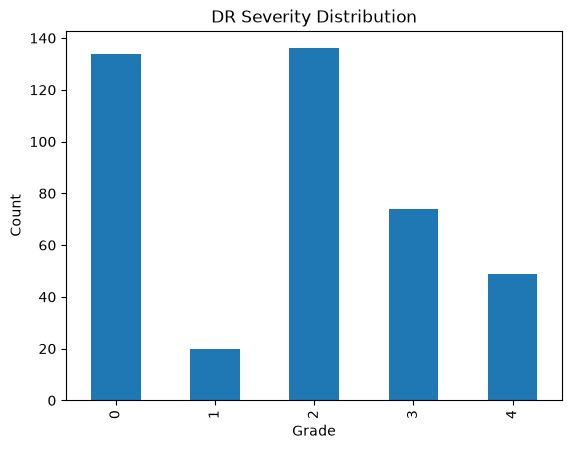

In [11]:
import matplotlib.pyplot as plt

train_df["Retinopathy grade"].value_counts().sort_index().plot(kind="bar")
plt.title("DR Severity Distribution")
plt.xlabel("Grade")
plt.ylabel("Count")
plt.show()

#The class distribution is imbalanced
#Grade 1 contains only 20 samples, while Grades 0 and 2 contain more than 130 samples each.

In [12]:
image_name = train_df.iloc[0]["Image name"]

print(image_name)

IDRiD_001


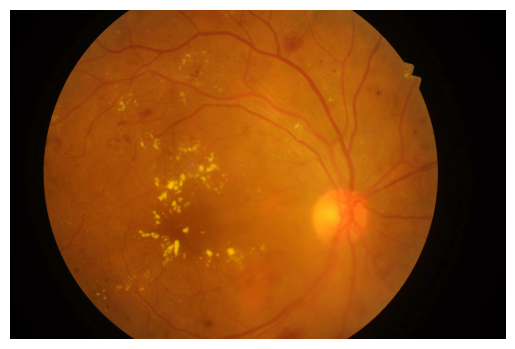

In [13]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open(
    f"../data/Disease_Grading/Original_Images/Training Set/{image_name}.jpg"
)

plt.imshow(img)
plt.axis("off")
plt.show()

In [14]:
img.size

(4288, 2848)

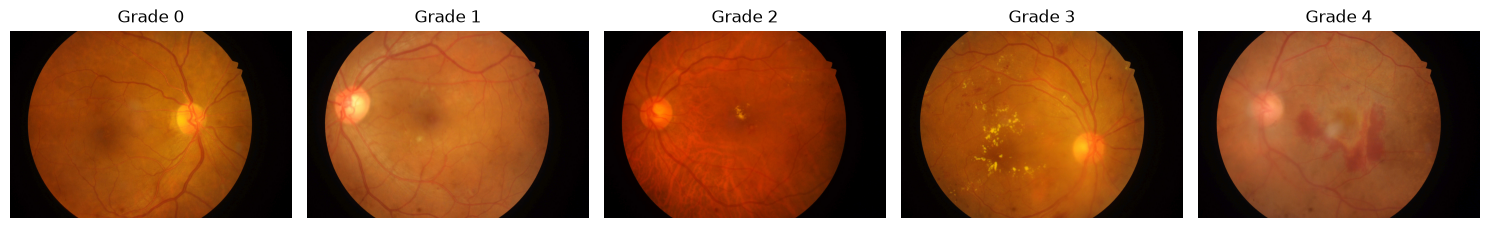

In [15]:
from PIL import Image
import matplotlib.pyplot as plt

grades = sorted(train_df["Retinopathy grade"].unique())

plt.figure(figsize=(15,4))

for i, grade in enumerate(grades):

    sample = train_df[
        train_df["Retinopathy grade"] == grade
    ].iloc[0]

    image_name = sample["Image name"]

    img = Image.open(
        f"../data/Disease_Grading/Original_Images/Training Set/{image_name}.jpg"
    )

    plt.subplot(1, len(grades), i+1)
    plt.imshow(img)
    plt.title(f"Grade {grade}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [15]:
from PIL import Image
import os

image_folder = "../data/Disease_Grading/Original_Images/Training Set"

sizes = set()

for file in os.listdir(image_folder):
    img = Image.open(os.path.join(image_folder, file))
    sizes.add(img.size)

print(sizes)

#all images are of same dimension

{(4288, 2848)}


In [16]:
#train-test split
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    train_df,
    test_size=0.2,
    stratify=train_df["Retinopathy grade"],
    random_state=42
)

In [17]:
#Albumentations
import albumentations as A
from albumentations.pytorch import ToTensorV2

In [ ]:
#Training transforms
train_transform = A.Compose([
    A.Resize(224,224),
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=15,p=0.5),
    A.ColorJitter(p=0.5),
    A.Normalize(),
    ToTensorV2()
])

In [19]:
#Validation transforms
val_transform = A.Compose([
    A.Resize(224,224),
    A.Normalize(),
    ToTensorV2()
])

In [20]:
train_df.head()
print(train_df.columns)

Index(['Image name', 'Retinopathy grade'], dtype='str')


In [30]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from utils.retina_dataset import RetinaDataset

In [ ]:
train_folder = "../data/Disease_Grading/Origina_Images/Training Set"
train_dataset = RetinaDataset(
    dataframe=train_df,
    image_dir=train_folder,
    transform=train_transform
)

val_dataset = RetinaDataset(
    dataframe=val_df,
    image_dir=train_folder,
    transform=val_transform
)

In [32]:
class_counts = (
    train_df["Retinopathy grade"]
    .value_counts()
    .sort_index()
)

print(class_counts)

Retinopathy grade
0    107
1     16
2    109
3     59
4     39
Name: count, dtype: int64


In [33]:
#creating class weights to handle class imbalance
import torch

class_weights = 1.0 / torch.tensor(
    class_counts.values,
    dtype=torch.float32
)

print(class_weights)

tensor([0.0093, 0.0625, 0.0092, 0.0169, 0.0256])


In [34]:
#creating sample weights for weighted random sampling
sample_weights = [
    class_weights[label]
    for label in train_df["Retinopathy grade"]
]

In [35]:
#creating sampler
from torch.utils.data import WeightedRandomSampler

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

In [36]:
#creating dataloaders
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    sampler=sampler
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False
)

In [29]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

error: OpenCV(4.13.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cv::cvtColor'


In [37]:
import os

print(os.listdir(train_folder)[:5])

NameError: name 'train_folder' is not defined